In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import sys
sys.path.insert(0, r"C:\Users\admin\work\idf_project\notebooks")
import config as cfg
from sqlalchemy import create_engine, text

engine = create_engine(cfg.DB_URL)

# Load full analysis dataset
df = pd.read_sql("""
    SELECT 
        ci.insee_com,
        ci.nom_com,
        ci.eai_score,
        ci.eai_rank,
        ci.score_food_access,
        ci.score_health_core,
        ci.score_health_complementary,
        ci.score_education_primary,
        ci.score_education_secondary,
        ci.score_education_higher,
        ci.score_social_services,
        ci.score_transport,
        ci.score_sports,
        ci.score_culture,
        ci.score_public_services,
        s.med_income_2021,
        s.poverty_rate,
        s.pop_total,
        s.pct_65plus,
        s.pct_0014,
        s.gini,
        c.insee_dep
    FROM idf.commune_index ci
    LEFT JOIN idf.socioeco s ON ci.insee_com = s.insee_com
    LEFT JOIN idf.communes c ON ci.insee_com = c.insee_com
""", engine)

# Filter Paris arrondissements out of analysis
# Keep 75056 (aggregated Paris) and drop 751xx
df = df[~df['insee_com'].str.startswith('751') | (df['insee_com'] == '75056')]

print(f"Analysis dataset: {len(df)} communes")
print(f"With income data: {df['med_income_2021'].notna().sum()}")
print(f"Département breakdown:")
print(df['insee_dep'].value_counts().sort_index())

Analysis dataset: 1266 communes
With income data: 1251
Département breakdown:
insee_dep
75      1
77    507
78    259
91    194
92     36
93     39
94     47
95    183
Name: count, dtype: int64


Pearson r = -0.101, R² = 0.010, p = 0.0004
Income explains 1.0% of EAI variance


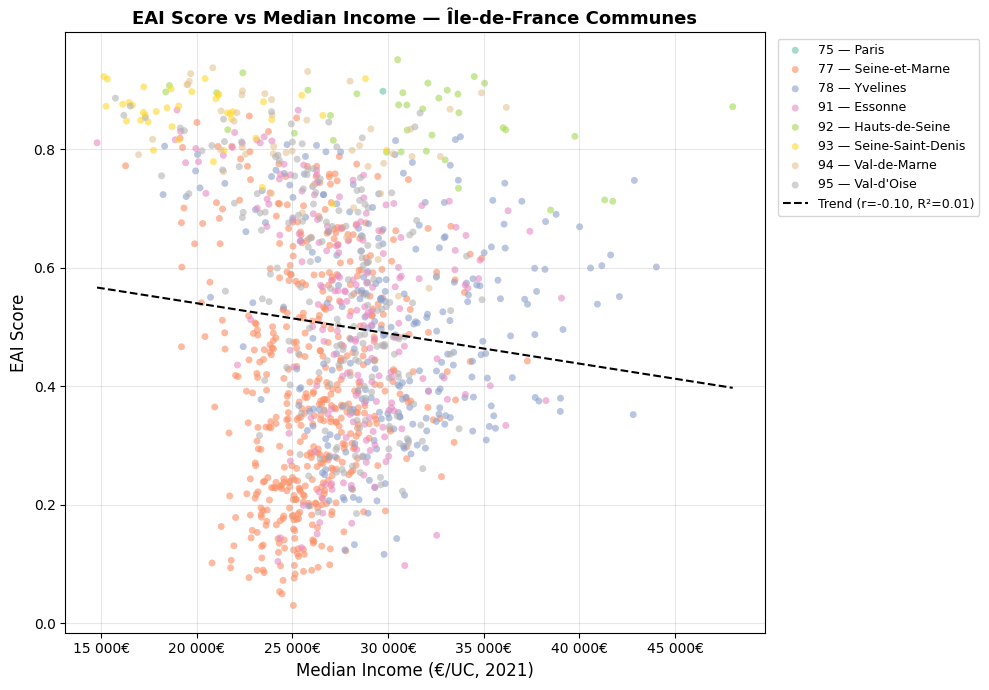

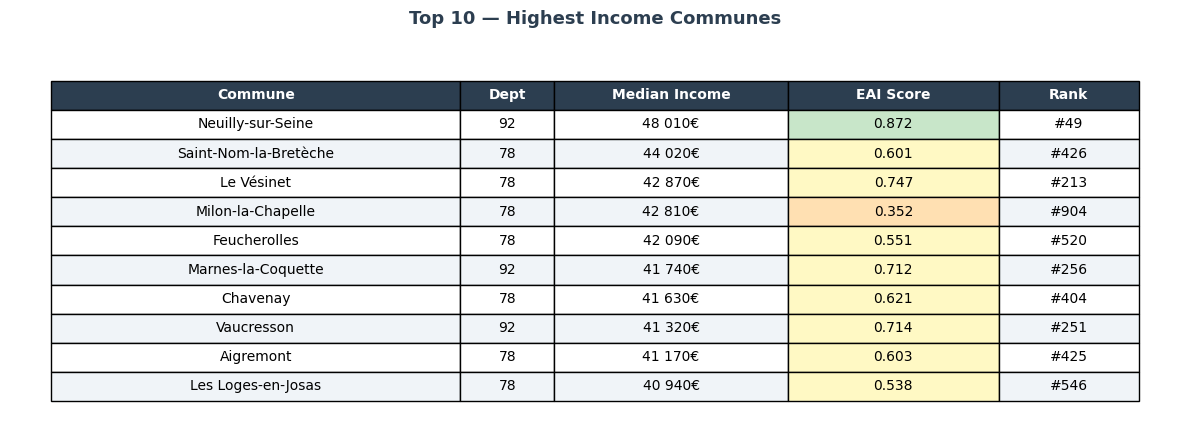

Saved: C:\Users\admin\work\idf_project\outputs\01b_top10_income.png


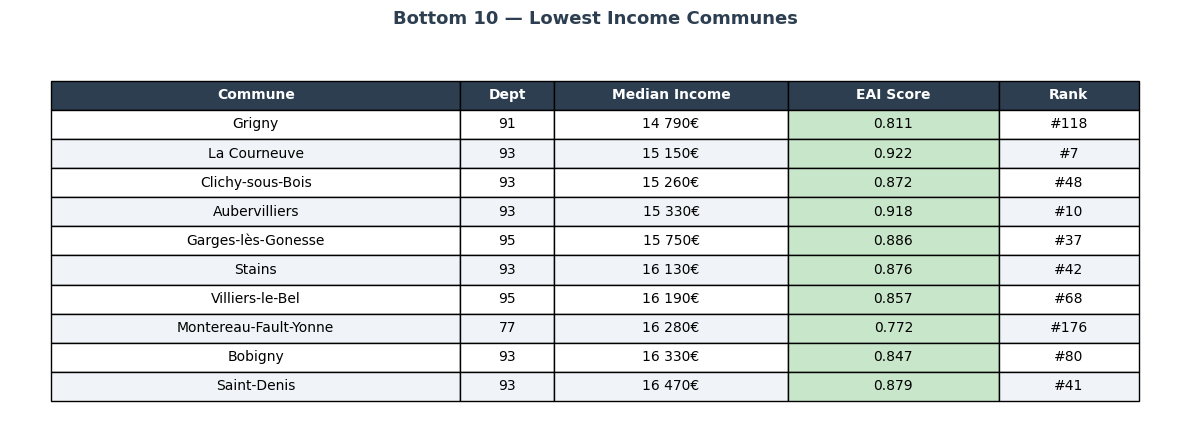

Saved: C:\Users\admin\work\idf_project\outputs\01c_bottom10_income.png


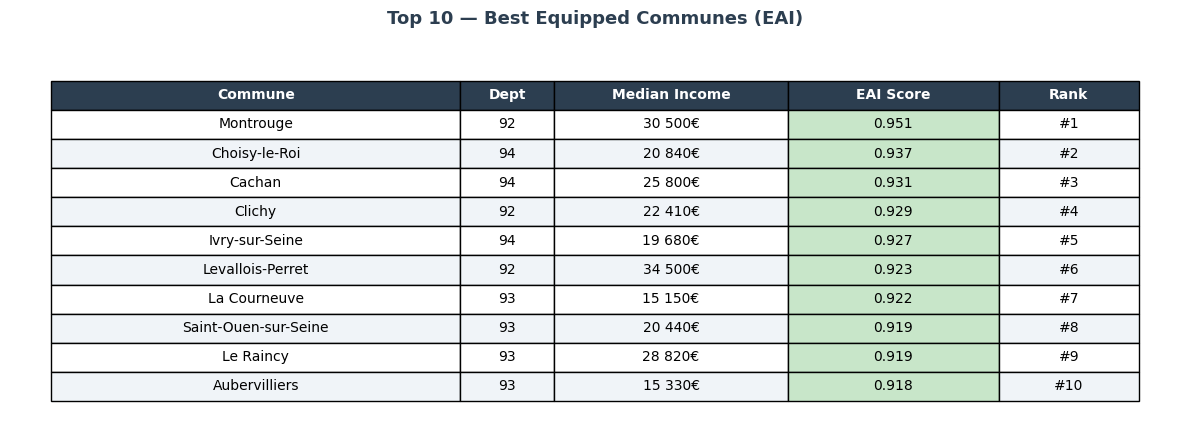

Saved: C:\Users\admin\work\idf_project\outputs\01d_top10_eai.png


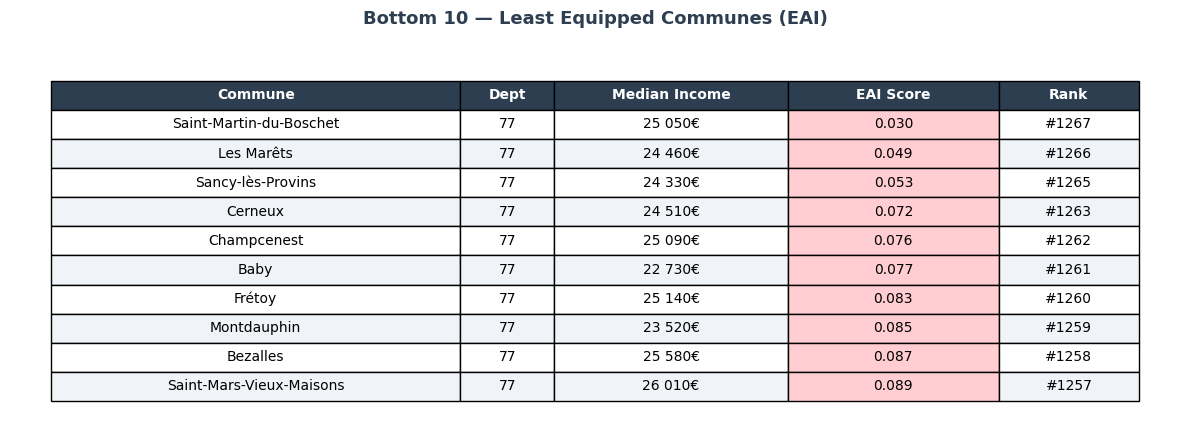

Saved: C:\Users\admin\work\idf_project\outputs\01e_bottom10_eai.png
Cell 2 complete


In [4]:
# ── Cell 2 — EAI vs Income correlation ───────────────────────────────────────

# Filter to communes with income data
df_income = df[df['med_income_2021'].notna()].copy()

# Département config
deps = df_income['insee_dep'].unique()
dep_color_map = {dep: plt.cm.Set2(i/len(deps))
                 for i, dep in enumerate(sorted(deps))}
dep_labels = {
    '75': '75 — Paris',
    '77': '77 — Seine-et-Marne',
    '78': '78 — Yvelines',
    '91': '91 — Essonne',
    '92': '92 — Hauts-de-Seine',
    '93': '93 — Seine-Saint-Denis',
    '94': '94 — Val-de-Marne',
    '95': "95 — Val-d'Oise"
}

# Pearson correlation
r, p = stats.pearsonr(df_income['eai_score'], df_income['med_income_2021'])
print(f"Pearson r = {r:.3f}, R² = {r**2:.3f}, p = {p:.4f}")
print(f"Income explains {r**2*100:.1f}% of EAI variance")

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for dep in sorted(deps):
    subset = df_income[df_income['insee_dep'] == dep]
    ax.scatter(
        subset['med_income_2021'],
        subset['eai_score'],
        c=[dep_color_map[dep]],
        label=dep_labels.get(dep, dep),
        alpha=0.6,
        s=25,
        edgecolors='none'
    )

z = np.polyfit(df_income['med_income_2021'], df_income['eai_score'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_income['med_income_2021'].min(),
                      df_income['med_income_2021'].max(), 100)
ax.plot(x_line, p_line(x_line), 'k--', linewidth=1.5,
        label=f'Trend (r={r:.2f}, R²={r**2:.2f})')

ax.set_xlabel('Median Income (€/UC, 2021)', fontsize=12)
ax.set_ylabel('EAI Score', fontsize=12)
ax.set_title('EAI Score vs Median Income — Île-de-France Communes',
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'{int(x):,}€'.replace(',', ' ')))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\admin\work\idf_project\outputs\01_eai_vs_income.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Table helper functions ────────────────────────────────────────────────────
def plot_table(data, title, filename):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.axis('off')

    rows = []
    for _, row in data.iterrows():
        income = f"{int(row['med_income_2021']):,}€".replace(',', ' ') \
                 if pd.notna(row['med_income_2021']) else 'N/A'
        rows.append([
            row['nom_com'],
            row['insee_dep'],
            income,
            f"{row['eai_score']:.3f}",
            f"#{int(row['eai_rank'])}"
        ])

    col_labels = ['Commune', 'Dept', 'Median Income', 'EAI Score', 'Rank']
    col_widths = [0.35, 0.08, 0.20, 0.18, 0.12]

    table = ax.table(
        cellText=rows,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
        colWidths=col_widths
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i in range(1, len(rows) + 1):
        for j in range(len(col_labels)):
            table[i, j].set_facecolor('#f0f4f8' if i % 2 == 0 else 'white')
            if j == 3:
                score = float(rows[i-1][3])
                if score >= 0.75:   table[i, j].set_facecolor('#c8e6c9')
                elif score >= 0.50: table[i, j].set_facecolor('#fff9c4')
                elif score >= 0.25: table[i, j].set_facecolor('#ffe0b2')
                else:               table[i, j].set_facecolor('#ffcdd2')

    ax.set_title(title, fontsize=13, fontweight='bold',
                 pad=20, color='#2c3e50')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {filename}")


def plot_custom_table(rows_data, col_labels, title, filename,
                      highlight_col_idx=None):
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.axis('off')

    table = ax.table(
        cellText=rows_data,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, 1.6)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i in range(1, len(rows_data) + 1):
        for j in range(len(col_labels)):
            table[i, j].set_facecolor('#f0f4f8' if i % 2 == 0 else 'white')
            if highlight_col_idx is not None and j == highlight_col_idx:
                try:
                    val = float(rows_data[i-1][j])
                    if val >= 0.75:   table[i, j].set_facecolor('#c8e6c9')
                    elif val >= 0.50: table[i, j].set_facecolor('#fff9c4')
                    elif val >= 0.25: table[i, j].set_facecolor('#ffe0b2')
                    else:             table[i, j].set_facecolor('#ffcdd2')
                except (ValueError, TypeError):
                    pass

    ax.set_title(title, fontsize=13, fontweight='bold',
                 pad=20, color='#2c3e50')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {filename}")

# ── Generate tables ───────────────────────────────────────────────────────────
plot_table(
    df_income.nlargest(10, 'med_income_2021'),
    "Top 10 — Highest Income Communes",
    r"C:\Users\admin\work\idf_project\outputs\01b_top10_income.png"
)
plot_table(
    df_income.nsmallest(10, 'med_income_2021'),
    "Bottom 10 — Lowest Income Communes",
    r"C:\Users\admin\work\idf_project\outputs\01c_bottom10_income.png"
)
plot_table(
    df_income.nsmallest(10, 'eai_rank'),
    "Top 10 — Best Equipped Communes (EAI)",
    r"C:\Users\admin\work\idf_project\outputs\01d_top10_eai.png"
)
plot_table(
    df_income.nlargest(10, 'eai_rank'),
    "Bottom 10 — Least Equipped Communes (EAI)",
    r"C:\Users\admin\work\idf_project\outputs\01e_bottom10_eai.png"
)

print("Cell 2 complete")

=== Bottom 20 communes by EAI ===
                       nom_com insee_dep  eai_score  pop_total  med_income_2021
403    Saint-Martin-du-Boschet        77   0.029989        264          25050.0
263                 Les Marêts        77   0.049484        154          24460.0
423          Sancy-lès-Provins        77   0.053351        338          24330.0
339            Passy-sur-Seine        77   0.060291         46              NaN
63                     Cerneux        77   0.072268        277          24510.0
76                 Champcenest        77   0.076080        197          25090.0
15                        Baby        77   0.076878        112          22730.0
186                     Frétoy        77   0.083086        173          25140.0
290                Montdauphin        77   0.085384        237          23520.0
31                    Bezalles        77   0.087465        224          25580.0
401   Saint-Mars-Vieux-Maisons        77   0.089284        248          26010.0
301   

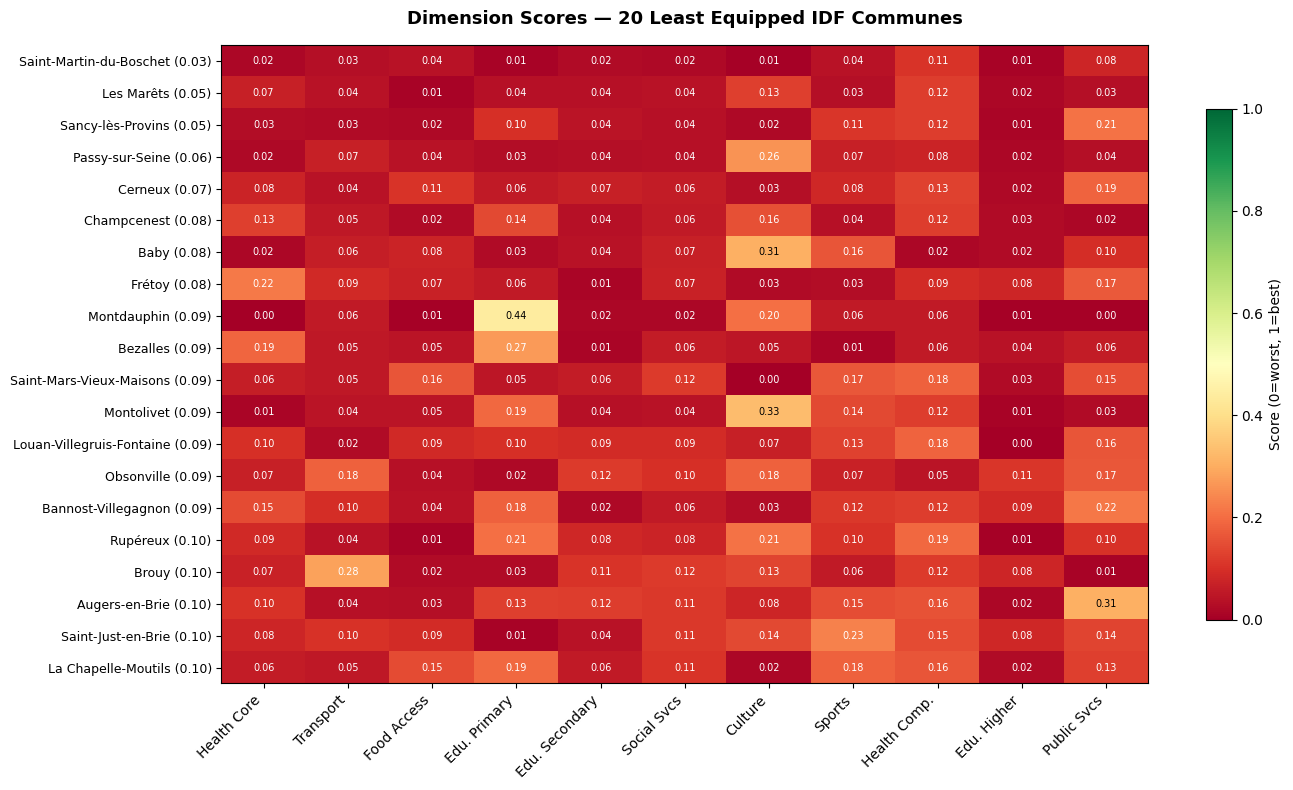

Saved: 02_bottom20_heatmap.png


In [5]:
# ── Bottom 20 communes — what are they missing? ───────────────────────────────

# Include ALL dimension columns in bottom20 selection
all_cols = ['nom_com', 'insee_dep', 'eai_score', 'eai_rank',
            'score_health_core', 'score_health_complementary',
            'score_transport', 'score_food_access',
            'score_education_primary', 'score_education_secondary',
            'score_education_higher', 'score_social_services',
            'score_culture', 'score_sports', 'score_public_services',
            'pop_total', 'med_income_2021']

bottom20 = df.nsmallest(20, 'eai_score')[all_cols].copy()

print("=== Bottom 20 communes by EAI ===")
print(bottom20[['nom_com', 'insee_dep', 'eai_score', 
                'pop_total', 'med_income_2021']].to_string())

# Heatmap of dimension scores for bottom 20
fig, ax = plt.subplots(figsize=(14, 8))

dim_cols = [
    'score_health_core', 'score_transport', 'score_food_access',
    'score_education_primary', 'score_education_secondary',
    'score_social_services', 'score_culture', 'score_sports',
    'score_health_complementary', 'score_education_higher',
    'score_public_services'
]

dim_labels = [
    'Health Core', 'Transport', 'Food Access',
    'Edu. Primary', 'Edu. Secondary',
    'Social Svcs', 'Culture', 'Sports',
    'Health Comp.', 'Edu. Higher',
    'Public Svcs'
]

heatmap_data = bottom20.set_index('nom_com')[dim_cols]
heatmap_data.columns = dim_labels

im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=1)

ax.set_xticks(range(len(dim_labels)))
ax.set_xticklabels(dim_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(bottom20)))
ax.set_yticklabels(
    [f"{r['nom_com']} ({r['eai_score']:.2f})" 
     for _, r in bottom20.iterrows()],
    fontsize=9
)

# Add score values in cells
for i in range(len(bottom20)):
    for j in range(len(dim_cols)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center',
                fontsize=7,
                color='black' if 0.3 < val < 0.7 else 'white')

plt.colorbar(im, ax=ax, shrink=0.8, label='Score (0=worst, 1=best)')
ax.set_title('Dimension Scores — 20 Least Equipped IDF Communes',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(r"C:\Users\admin\work\idf_project\outputs\02_bottom20_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_bottom20_heatmap.png")

Transport desert threshold (Q25): 0.353
Communes in transport desert: 317

=== Transport desert communes vs rest ===
eai_score                          : desert=0.270  rest=0.576  gap=-0.307
score_health_core                  : desert=0.267  rest=0.578  gap=-0.311
score_food_access                  : desert=0.275  rest=0.575  gap=-0.300
score_education_secondary          : desert=0.239  rest=0.587  gap=-0.347
med_income_2021                    : desert=26902.020  rest=27499.280  gap=-597.260


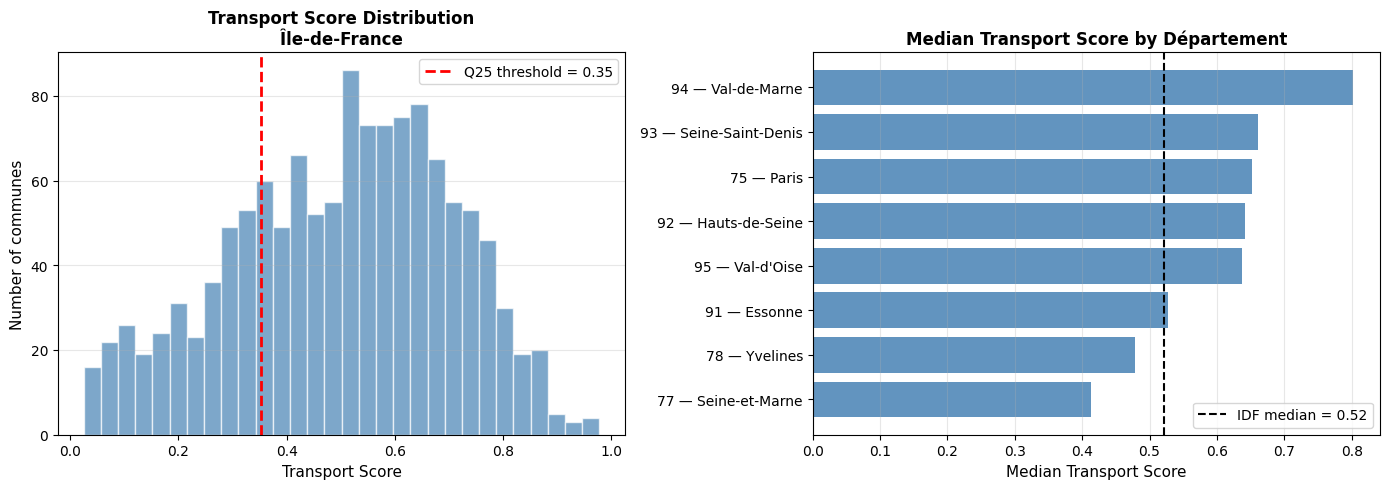

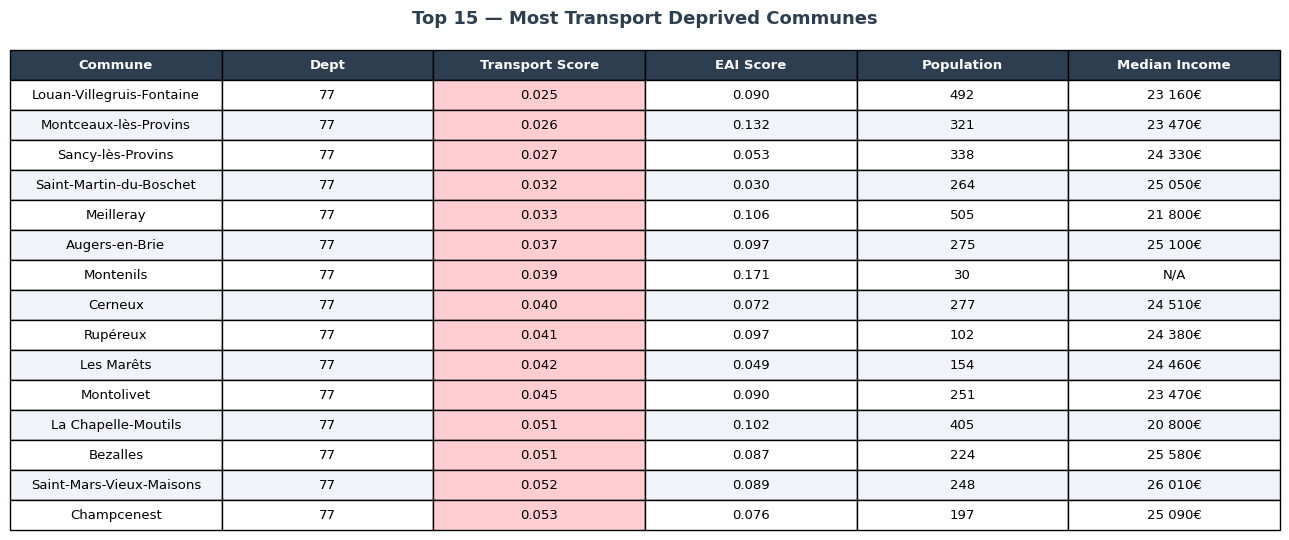

Saved: C:\Users\admin\work\idf_project\outputs\03b_transport_desert.png

=== Transport desert by département ===
insee_dep
77 — Seine-et-Marne    211
78 — Yvelines           60
91 — Essonne            23
95 — Val-d'Oise         23


In [6]:
# ── Transport deserts ─────────────────────────────────────────────────────────

dep_labels = {
    '75': '75 — Paris',
    '77': '77 — Seine-et-Marne',
    '78': '78 — Yvelines',
    '91': '91 — Essonne',
    '92': '92 — Hauts-de-Seine',
    '93': '93 — Seine-Saint-Denis',
    '94': '94 — Val-de-Marne',
    '95': "95 — Val-d'Oise"
}

# Define transport desert: bottom quartile on transport score
transport_q25 = df['score_transport'].quantile(0.25)
transport_desert = df[df['score_transport'] <= transport_q25].copy()
rest = df[df['score_transport'] > transport_q25]

print(f"Transport desert threshold (Q25): {transport_q25:.3f}")
print(f"Communes in transport desert: {len(transport_desert)}")

print(f"\n=== Transport desert communes vs rest ===")
for col in ['eai_score', 'score_health_core', 'score_food_access',
            'score_education_secondary', 'med_income_2021']:
    desert_mean = transport_desert[col].mean()
    rest_mean = rest[col].mean()
    print(f"{col:35s}: desert={desert_mean:.3f}  rest={rest_mean:.3f}  "
          f"gap={desert_mean-rest_mean:+.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['score_transport'], bins=30, color='steelblue',
             alpha=0.7, edgecolor='white')
axes[0].axvline(transport_q25, color='red', linestyle='--',
                linewidth=2, label=f'Q25 threshold = {transport_q25:.2f}')
axes[0].set_xlabel('Transport Score', fontsize=11)
axes[0].set_ylabel('Number of communes', fontsize=11)
axes[0].set_title('Transport Score Distribution\nÎle-de-France',
                   fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

dep_transport = df.groupby('insee_dep')['score_transport'].median()\
                  .sort_values().reset_index()
dep_transport.columns = ['insee_dep', 'median_transport']

bar_colors = ['#d7191c' if v < transport_q25 else 'steelblue'
              for v in dep_transport['median_transport']]

axes[1].barh(
    [dep_labels.get(d, d) for d in dep_transport['insee_dep']],
    dep_transport['median_transport'],
    color=bar_colors,
    alpha=0.85
)
axes[1].axvline(df['score_transport'].median(), color='black',
                linestyle='--', linewidth=1.5,
                label=f'IDF median = {df["score_transport"].median():.2f}')
axes[1].set_xlabel('Median Transport Score', fontsize=11)
axes[1].set_title('Median Transport Score by Département',
                   fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(r"C:\Users\admin\work\idf_project\outputs\03_transport_deserts.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Generic table function ────────────────────────────────────────────────────
def plot_custom_table(rows_data, col_labels, title, filename,
                      highlight_col_idx=None):
    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.axis('off')

    table = ax.table(
        cellText=rows_data,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, 1.6)

    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i in range(1, len(rows_data) + 1):
        for j in range(len(col_labels)):
            table[i, j].set_facecolor('#f0f4f8' if i % 2 == 0 else 'white')
            if highlight_col_idx is not None and j == highlight_col_idx:
                try:
                    val = float(rows_data[i-1][j])
                    if val >= 0.75:   table[i, j].set_facecolor('#c8e6c9')
                    elif val >= 0.50: table[i, j].set_facecolor('#fff9c4')
                    elif val >= 0.25: table[i, j].set_facecolor('#ffe0b2')
                    else:             table[i, j].set_facecolor('#ffcdd2')
                except (ValueError, TypeError):
                    pass

    ax.set_title(title, fontsize=13, fontweight='bold',
                 pad=20, color='#2c3e50')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {filename}")

# ── Transport desert table ────────────────────────────────────────────────────
top15_desert = transport_desert.nsmallest(15, 'score_transport')

transport_rows = []
for _, row in top15_desert.iterrows():
    income = f"{int(row['med_income_2021']):,}€".replace(',', ' ') \
             if pd.notna(row['med_income_2021']) else 'N/A'
    pop = f"{int(row['pop_total']):,}".replace(',', ' ') \
          if pd.notna(row['pop_total']) else 'N/A'
    transport_rows.append([
        row['nom_com'],
        row['insee_dep'],
        f"{row['score_transport']:.3f}",
        f"{row['eai_score']:.3f}",
        pop,
        income
    ])

plot_custom_table(
    transport_rows,
    ['Commune', 'Dept', 'Transport Score', 'EAI Score', 'Population', 'Median Income'],
    "Top 15 — Most Transport Deprived Communes",
    r"C:\Users\admin\work\idf_project\outputs\03b_transport_desert.png",
    highlight_col_idx=2
)

print("\n=== Transport desert by département ===")
print(transport_desert['insee_dep'].value_counts()
      .rename(index=dep_labels).to_string())

=== Lycée travel time statistics ===
       time_lycee_gen  time_lycee_pro  time_college
count         1266.00         1266.00       1266.00
mean             9.76           16.24          6.11
std              6.01            9.59          3.70
min              1.30            1.58          1.22
25%              4.50            8.85          2.75
50%              9.06           14.83          5.54
75%             13.64           21.54          8.47
max             34.17           52.93         21.59

Communes where lycée pro is MORE than 10 min closer than général:
  3 communes (0.2%)

Communes where lycée général is MORE than 10 min closer than pro:
  305 communes (24.1%)


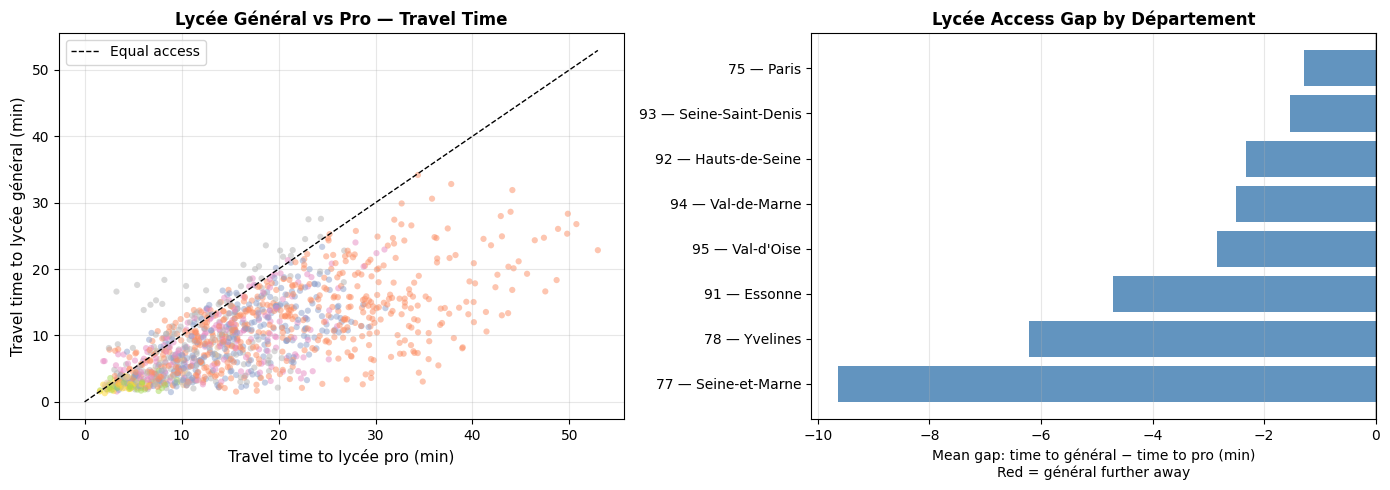

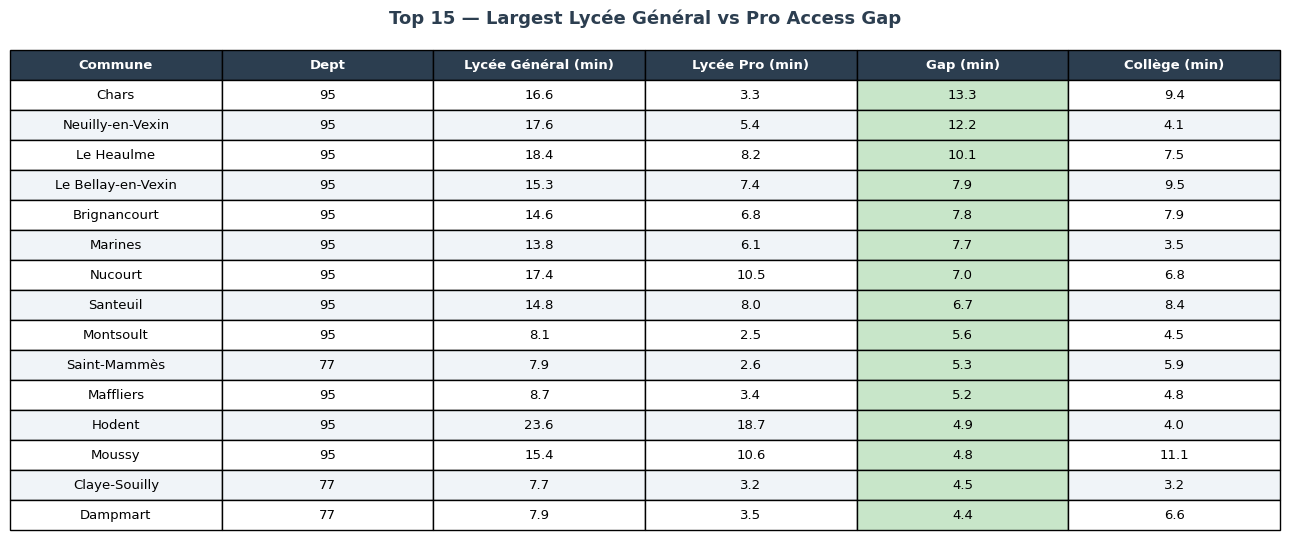

Saved: C:\Users\admin\work\idf_project\outputs\04b_lycee_gap.png

=== Mean lycée gap by département ===
insee_dep
75 — Paris               -1.29
93 — Seine-Saint-Denis   -1.54
92 — Hauts-de-Seine      -2.33
94 — Val-de-Marne        -2.50
95 — Val-d'Oise          -2.84
91 — Essonne             -4.72
78 — Yvelines            -6.21
77 — Seine-et-Marne      -9.64


In [7]:
# ── Education access gaps ─────────────────────────────────────────────────────

lycee_data = pd.read_sql("""
    SELECT 
        a.insee_com,
        c.nom_com,
        c.insee_dep,
        MAX(CASE WHEN a.typeeq_id = 'C301' THEN a.avg_travel_min END) as time_lycee_gen,
        MAX(CASE WHEN a.typeeq_id = 'C302' THEN a.avg_travel_min END) as time_lycee_pro,
        MAX(CASE WHEN a.typeeq_id = 'C201' THEN a.avg_travel_min END) as time_college
    FROM idf.accessibility_grid a
    JOIN idf.communes c ON a.insee_com = c.insee_com
    WHERE a.typeeq_id IN ('C201', 'C301', 'C302')
    GROUP BY a.insee_com, c.nom_com, c.insee_dep
""", engine)

# Remove Paris arrondissements
lycee_data = lycee_data[
    ~lycee_data['insee_com'].str.startswith('751') |
    (lycee_data['insee_com'] == '75056')
].copy()

lycee_data['lycee_gap'] = lycee_data['time_lycee_gen'] - lycee_data['time_lycee_pro']

print("=== Lycée travel time statistics ===")
print(lycee_data[['time_lycee_gen','time_lycee_pro','time_college']]\
      .describe().round(2).to_string())

print(f"\nCommunes where lycée pro is MORE than 10 min closer than général:")
pro_closer = lycee_data[lycee_data['lycee_gap'] > 10]
print(f"  {len(pro_closer)} communes ({len(pro_closer)/len(lycee_data)*100:.1f}%)")

print(f"\nCommunes where lycée général is MORE than 10 min closer than pro:")
gen_closer = lycee_data[lycee_data['lycee_gap'] < -10]
print(f"  {len(gen_closer)} communes ({len(gen_closer)/len(lycee_data)*100:.1f}%)")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    lycee_data['time_lycee_pro'],
    lycee_data['time_lycee_gen'],
    c=lycee_data['insee_dep'].astype('category').cat.codes,
    cmap='Set2', alpha=0.5, s=20, edgecolors='none'
)
max_val = max(lycee_data['time_lycee_gen'].max(),
              lycee_data['time_lycee_pro'].max())
axes[0].plot([0, max_val], [0, max_val], 'k--',
             linewidth=1, label='Equal access')
axes[0].set_xlabel('Travel time to lycée pro (min)', fontsize=11)
axes[0].set_ylabel('Travel time to lycée général (min)', fontsize=11)
axes[0].set_title('Lycée Général vs Pro — Travel Time',
                   fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

dep_gap = lycee_data.groupby('insee_dep')['lycee_gap'].mean().sort_values()
bar_colors = ['#d7191c' if x > 0 else 'steelblue' for x in dep_gap.values]
axes[1].barh(
    [dep_labels.get(d, d) for d in dep_gap.index],
    dep_gap.values,
    color=bar_colors,
    alpha=0.85
)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Mean gap: time to général − time to pro (min)\n'
                    'Red = général further away', fontsize=10)
axes[1].set_title('Lycée Access Gap by Département',
                   fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(r"C:\Users\admin\work\idf_project\outputs\04_education_gaps.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Table: communes with largest lycée gap ────────────────────────────────────
top15_gap = lycee_data.nlargest(15, 'lycee_gap')

gap_rows = []
for _, row in top15_gap.iterrows():
    gap_rows.append([
        row['nom_com'],
        row['insee_dep'],
        f"{row['time_lycee_gen']:.1f}",
        f"{row['time_lycee_pro']:.1f}",
        f"{row['lycee_gap']:.1f}",
        f"{row['time_college']:.1f}"
    ])

plot_custom_table(
    gap_rows,
    ['Commune', 'Dept', 'Lycée Général (min)',
     'Lycée Pro (min)', 'Gap (min)', 'Collège (min)'],
    "Top 15 — Largest Lycée Général vs Pro Access Gap",
    r"C:\Users\admin\work\idf_project\outputs\04b_lycee_gap.png",
    highlight_col_idx=4
)

print("\n=== Mean lycée gap by département ===")
print(lycee_data.groupby('insee_dep')['lycee_gap'].mean()
      .rename(index=dep_labels).sort_values(ascending=False).round(2).to_string())

=== Quadrant counts ===
quadrant
Average                   915
High EAI / Low Income     150
Low EAI / Low Income       79
High EAI / High Income     63
Low EAI / High Income      44
Name: count, dtype: int64

=== High EAI / Low Income ===
                        nom_com insee_dep  eai_score  med_income_2021  score_social_services  score_transport
1047              Choisy-le-Roi        94   0.937317          20840.0               0.965245         0.927857
971                      Clichy        92   0.928831          22410.0               0.962875         0.691153
1053             Ivry-sur-Seine        94   0.927350          19680.0               0.937994         0.878357
1006               La Courneuve        93   0.922413          15150.0               0.940956         0.657715
1028       Saint-Ouen-sur-Seine        93   0.919216          20440.0               0.951619         0.682201
997               Aubervilliers        93   0.918285          15330.0               0.964850        

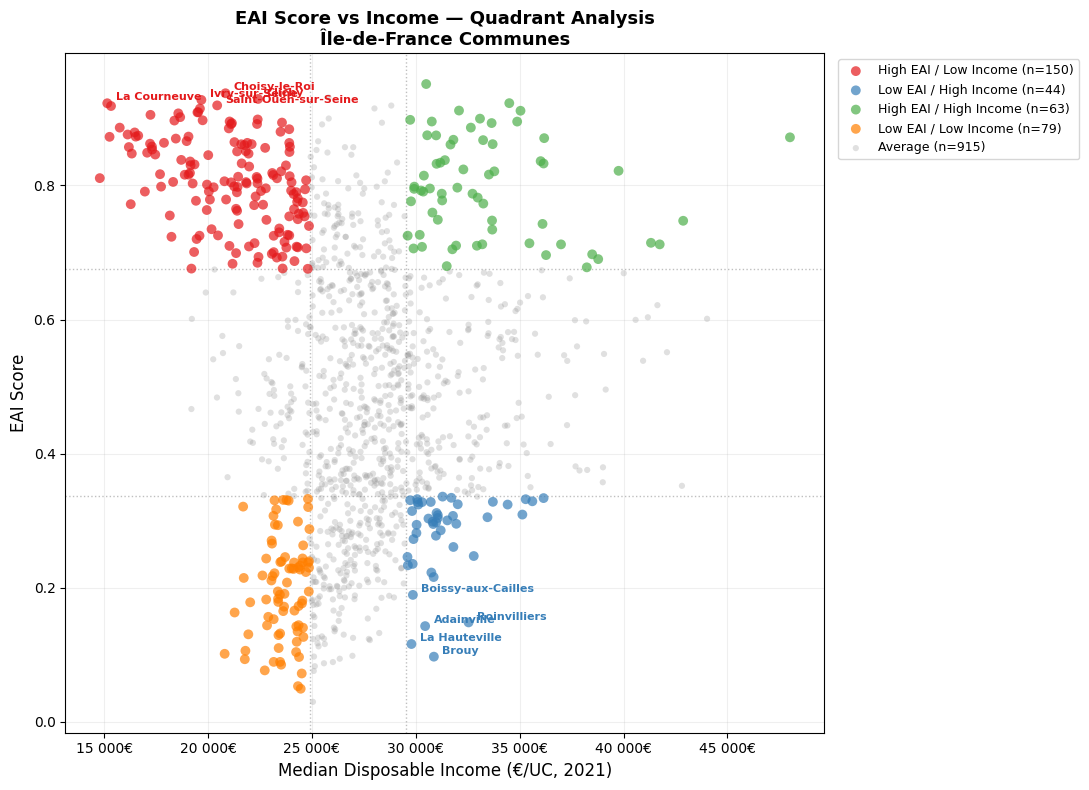

C:\Users\admin\AppData\Local\Temp\ipykernel_26192\2638805217.py:107: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


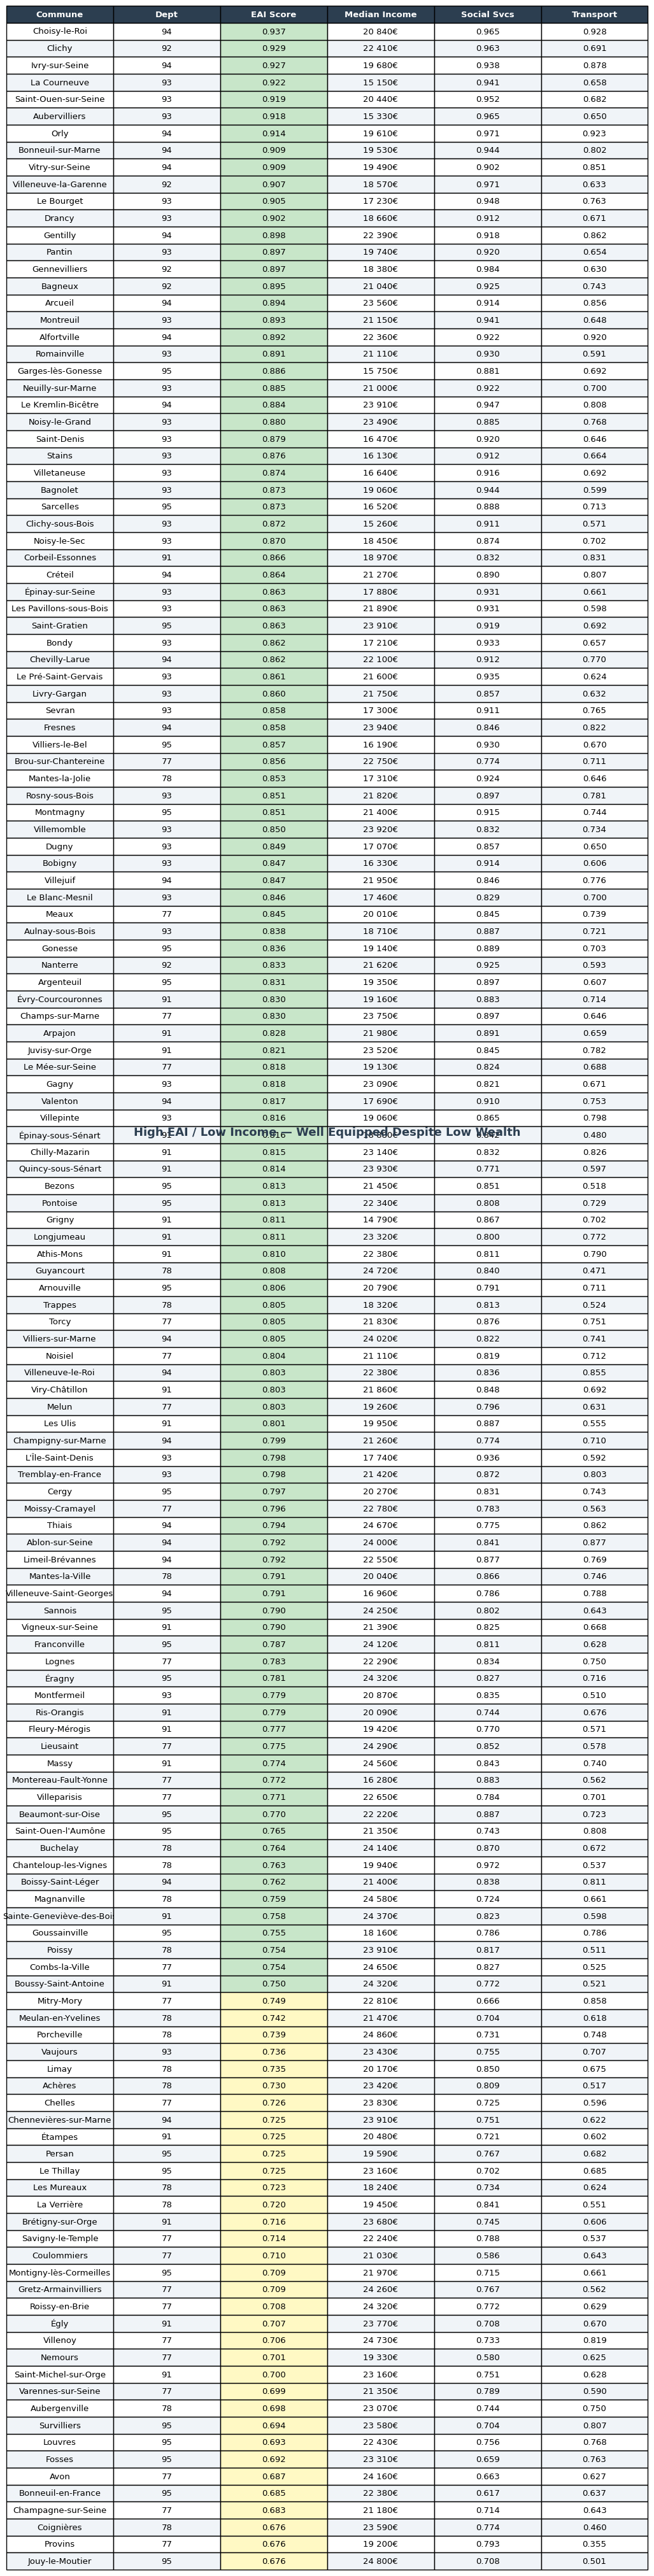

Saved: C:\Users\admin\work\idf_project\outputs\05b_high_eai_low_income.png


C:\Users\admin\AppData\Local\Temp\ipykernel_26192\2638805217.py:107: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


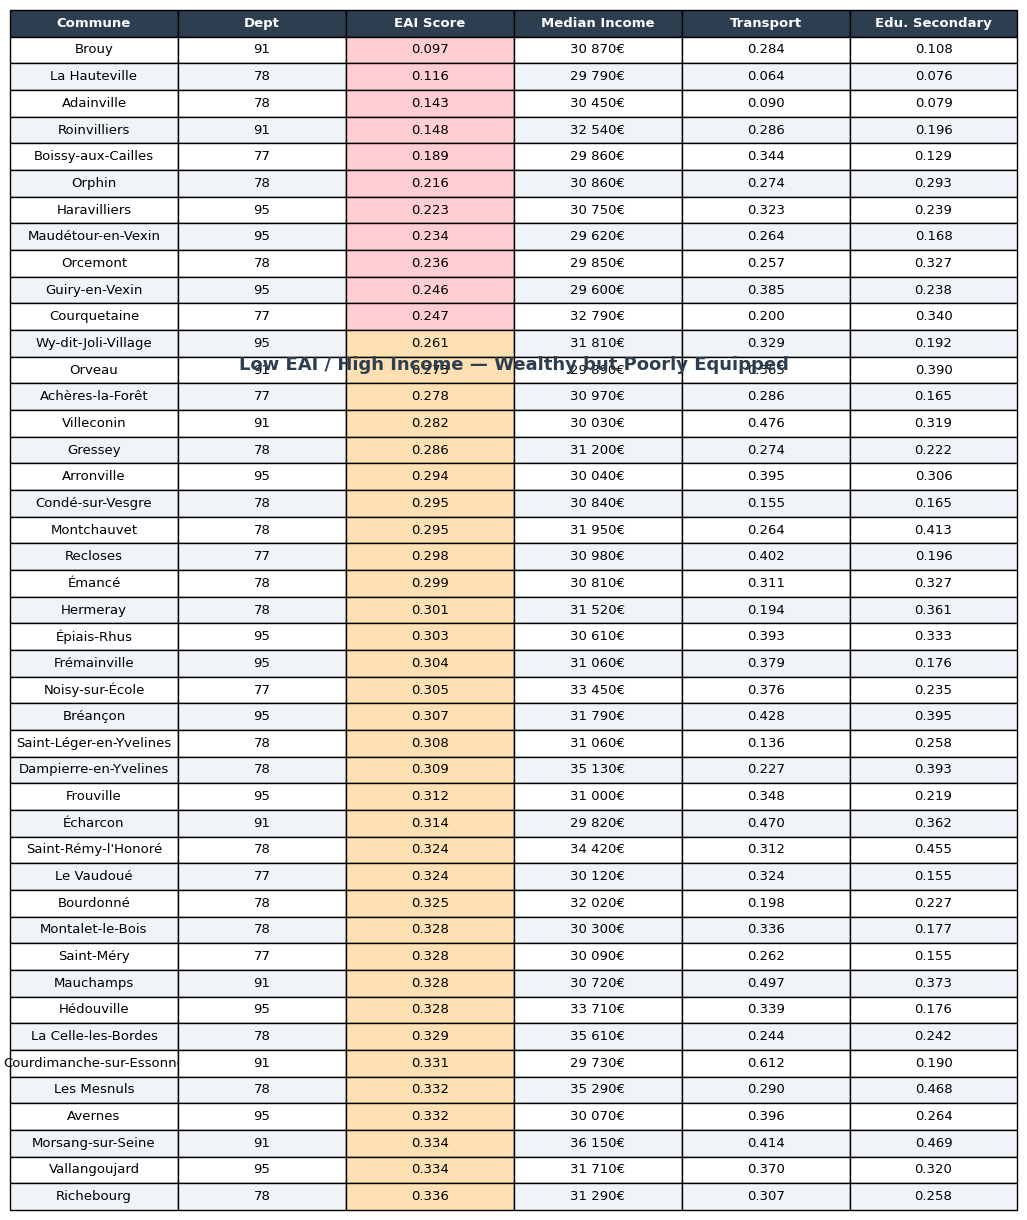

Saved: C:\Users\admin\work\idf_project\outputs\05c_low_eai_high_income.png

Cell 6 complete


In [8]:
# ── Surprising findings: quadrant analysis ────────────────────────────────────

df_inc = df[df['med_income_2021'].notna()].copy()

df_inc['income_pct'] = df_inc['med_income_2021'].rank(pct=True)
df_inc['eai_pct'] = df_inc['eai_score'].rank(pct=True)

df_inc['quadrant'] = 'Average'
df_inc.loc[(df_inc['eai_pct'] >= 0.75) &
           (df_inc['income_pct'] <= 0.25), 'quadrant'] = 'High EAI / Low Income'
df_inc.loc[(df_inc['eai_pct'] <= 0.25) &
           (df_inc['income_pct'] >= 0.75), 'quadrant'] = 'Low EAI / High Income'
df_inc.loc[(df_inc['eai_pct'] >= 0.75) &
           (df_inc['income_pct'] >= 0.75), 'quadrant'] = 'High EAI / High Income'
df_inc.loc[(df_inc['eai_pct'] <= 0.25) &
           (df_inc['income_pct'] <= 0.25), 'quadrant'] = 'Low EAI / Low Income'

print("=== Quadrant counts ===")
print(df_inc['quadrant'].value_counts())

print("\n=== High EAI / Low Income ===")
hi_eai_lo_inc = df_inc[df_inc['quadrant'] == 'High EAI / Low Income']\
    .sort_values('eai_score', ascending=False)
print(hi_eai_lo_inc[['nom_com', 'insee_dep', 'eai_score',
                       'med_income_2021', 'score_social_services',
                       'score_transport']].to_string())

print("\n=== Low EAI / High Income ===")
lo_eai_hi_inc = df_inc[df_inc['quadrant'] == 'Low EAI / High Income']\
    .sort_values('eai_score')
print(lo_eai_hi_inc[['nom_com', 'insee_dep', 'eai_score',
                       'med_income_2021', 'score_transport',
                       'score_education_secondary']].to_string())

# ── Quadrant scatter plot ─────────────────────────────────────────────────────
quadrant_colors = {
    'High EAI / Low Income':  '#e41a1c',
    'Low EAI / High Income':  '#377eb8',
    'High EAI / High Income': '#4daf4a',
    'Low EAI / Low Income':   '#ff7f00',
    'Average':                '#999999'
}

fig, ax = plt.subplots(figsize=(11, 8))

for quad, color in quadrant_colors.items():
    subset = df_inc[df_inc['quadrant'] == quad]
    ax.scatter(
        subset['med_income_2021'],
        subset['eai_score'],
        c=color,
        label=f"{quad} (n={len(subset)})",
        alpha=0.7 if quad != 'Average' else 0.3,
        s=50 if quad != 'Average' else 20,
        edgecolors='none',
        zorder=3 if quad != 'Average' else 1
    )

# Annotate top 5 most interesting per quadrant
for _, row in hi_eai_lo_inc.head(5).iterrows():
    ax.annotate(row['nom_com'],
                xy=(row['med_income_2021'], row['eai_score']),
                xytext=(6, 2), textcoords='offset points',
                fontsize=8, color='#e41a1c', fontweight='bold')

for _, row in lo_eai_hi_inc.head(5).iterrows():
    ax.annotate(row['nom_com'],
                xy=(row['med_income_2021'], row['eai_score']),
                xytext=(6, 2), textcoords='offset points',
                fontsize=8, color='#377eb8', fontweight='bold')

# Quadrant boundary lines
ax.axhline(df_inc['eai_score'].quantile(0.75),
           color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(df_inc['eai_score'].quantile(0.25),
           color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.axvline(df_inc['med_income_2021'].quantile(0.75),
           color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.axvline(df_inc['med_income_2021'].quantile(0.25),
           color='gray', linestyle=':', alpha=0.5, linewidth=1)

ax.set_xlabel('Median Disposable Income (€/UC, 2021)', fontsize=12)
ax.set_ylabel('EAI Score', fontsize=12)
ax.set_title('EAI Score vs Income — Quadrant Analysis\nÎle-de-France Communes',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'{int(x):,}€'.replace(',', ' ')))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(r"C:\Users\admin\work\idf_project\outputs\05_quadrant_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Formatted tables for both quadrants ──────────────────────────────────────
hi_rows = []
for _, row in hi_eai_lo_inc.iterrows():
    hi_rows.append([
        row['nom_com'],
        row['insee_dep'],
        f"{row['eai_score']:.3f}",
        f"{int(row['med_income_2021']):,}€".replace(',', ' '),
        f"{row['score_social_services']:.3f}",
        f"{row['score_transport']:.3f}"
    ])

plot_custom_table(
    hi_rows,
    ['Commune', 'Dept', 'EAI Score', 'Median Income',
     'Social Svcs', 'Transport'],
    "High EAI / Low Income — Well Equipped Despite Low Wealth",
    r"C:\Users\admin\work\idf_project\outputs\05b_high_eai_low_income.png",
    highlight_col_idx=2
)

lo_rows = []
for _, row in lo_eai_hi_inc.iterrows():
    lo_rows.append([
        row['nom_com'],
        row['insee_dep'],
        f"{row['eai_score']:.3f}",
        f"{int(row['med_income_2021']):,}€".replace(',', ' '),
        f"{row['score_transport']:.3f}",
        f"{row['score_education_secondary']:.3f}"
    ])

plot_custom_table(
    lo_rows,
    ['Commune', 'Dept', 'EAI Score', 'Median Income',
     'Transport', 'Edu. Secondary'],
    "Low EAI / High Income — Wealthy but Poorly Equipped",
    r"C:\Users\admin\work\idf_project\outputs\05c_low_eai_high_income.png",
    highlight_col_idx=2
)

print("\nCell 6 complete")

In [9]:
# ── Cell 7 — Summary report ───────────────────────────────────────────────────
print("=" * 65)
print("  ÉQUIPEMENT & ACCESSIBILITÉ INDEX — IDF SUMMARY REPORT")
print("=" * 65)

print(f"\n📊 DATASET")
print(f"  Communes analysed:        {len(df):,}")
print(f"  Facility types:           60")
print(f"  Index dimensions:         11")
print(f"  Data sources:             INSEE BPE 2024, Filosofi 2021,")
print(f"                            RP 2022, Accessibility Grid 2023")

print(f"\n📈 EAI SCORE DISTRIBUTION")
print(f"  Mean:    {df['eai_score'].mean():.3f}")
print(f"  Median:  {df['eai_score'].median():.3f}")
print(f"  Std dev: {df['eai_score'].std():.3f}")
print(f"  Min:     {df['eai_score'].min():.3f} "
      f"— {df.loc[df['eai_score'].idxmin(), 'nom_com']}")
print(f"  Max:     {df['eai_score'].max():.3f} "
      f"— {df.loc[df['eai_score'].idxmax(), 'nom_com']}")

print(f"\n🏆 TOP 5 BEST EQUIPPED")
for _, r in df.nsmallest(5, 'eai_rank')[
        ['nom_com','eai_score','eai_rank','insee_dep']].iterrows():
    print(f"  #{int(r['eai_rank']):4d}  {r['nom_com']:<30} "
          f"Dept {r['insee_dep']}  {r['eai_score']:.3f}")

print(f"\n⚠️  BOTTOM 5 LEAST EQUIPPED")
for _, r in df.nlargest(5, 'eai_rank')[
        ['nom_com','eai_score','eai_rank','insee_dep']].iterrows():
    print(f"  #{int(r['eai_rank']):4d}  {r['nom_com']:<30} "
          f"Dept {r['insee_dep']}  {r['eai_score']:.3f}")

df_c = df[df['med_income_2021'].notna()]
r_corr, p_corr = stats.pearsonr(df_c['eai_score'], df_c['med_income_2021'])
print(f"\n🔗 EAI vs INCOME CORRELATION")
print(f"  Pearson r:   {r_corr:.3f}")
print(f"  R²:          {r_corr**2:.3f}")
print(f"  Interpretation: Income explains only {r_corr**2*100:.1f}% "
      f"of EAI variance")
print(f"  → Equipment access is largely independent of wealth")

print(f"\n🚆 TRANSPORT DESERTS")
print(f"  Communes in bottom Q25:   {len(transport_desert)}")
print(f"  EAI gap vs rest:          "
      f"{transport_desert['eai_score'].mean() - rest['eai_score'].mean():+.3f}")
print(f"  Income gap vs rest:       "
      f"{transport_desert['med_income_2021'].mean() - rest['med_income_2021'].mean():+.0f}€")
print(f"  → Transport poverty ≠ income poverty")
print(f"  Most affected:  "
      f"{transport_desert['insee_dep'].value_counts().index[0]} — "
      f"{transport_desert['insee_dep'].value_counts().iloc[0]} communes")

print(f"\n📚 EDUCATION GAPS")
print(f"  Mean travel — lycée général:  {lycee_data['time_lycee_gen'].mean():.1f} min")
print(f"  Mean travel — lycée pro:      {lycee_data['time_lycee_pro'].mean():.1f} min")
print(f"  Gap:                          "
      f"{lycee_data['time_lycee_gen'].mean() - lycee_data['time_lycee_pro'].mean():+.1f} min")
print(f"  Communes where général >10min closer: "
      f"{len(lycee_data[lycee_data['lycee_gap'] < -10])} "
      f"({len(lycee_data[lycee_data['lycee_gap'] < -10])/len(lycee_data)*100:.1f}%)")
print(f"  Worst département: 77 — Seine-et-Marne "
      f"(gap = {lycee_data[lycee_data['insee_dep']=='77']['lycee_gap'].mean():.1f} min)")

print(f"\n🔴 SURPRISING FINDINGS")
print(f"  High EAI / Low Income:  {len(df_inc[df_inc['quadrant']=='High EAI / Low Income'])} communes")
print(f"  → Policy investment visible in deprived Seine-Saint-Denis communes")
print(f"  Low EAI / High Income:  {len(df_inc[df_inc['quadrant']=='Low EAI / High Income'])} communes")
print(f"  → Wealthy rural villages structurally underserved by public equipment")

print(f"\n📁 OUTPUT FILES")
outputs = [
    "01_eai_vs_income.png      — Scatter plot EAI vs income",
    "01b_top10_income.png      — Highest income communes table",
    "01c_bottom10_income.png   — Lowest income communes table",
    "01d_top10_eai.png         — Best equipped communes table",
    "01e_bottom10_eai.png      — Least equipped communes table",
    "02_bottom20_heatmap.png   — Dimension heatmap bottom 20",
    "03_transport_deserts.png  — Transport score distribution",
    "03b_transport_desert.png  — Transport desert communes table",
    "04_education_gaps.png     — Lycée access gap analysis",
    "04b_lycee_gap.png         — Largest lycée gap communes table",
    "05_quadrant_analysis.png  — EAI vs income quadrant scatter",
    "05b_high_eai_low_income.png — High EAI / Low income table",
    "05c_low_eai_high_income.png — Low EAI / High income table",
    "idf_eai_map.html          — Interactive EAI map (43MB)",
    "idf_facilities_map.html   — Interactive facilities map (92MB)",
]
for f in outputs:
    print(f"  {f}")

print(f"\n{'='*65}")
print("  Analysis complete.")
print(f"{'='*65}")

  ÉQUIPEMENT & ACCESSIBILITÉ INDEX — IDF SUMMARY REPORT

📊 DATASET
  Communes analysed:        1,266
  Facility types:           60
  Index dimensions:         11
  Data sources:             INSEE BPE 2024, Filosofi 2021,
                            RP 2022, Accessibility Grid 2023

📈 EAI SCORE DISTRIBUTION
  Mean:    0.500
  Median:  0.484
  Std dev: 0.216
  Min:     0.030 — Saint-Martin-du-Boschet
  Max:     0.951 — Montrouge

🏆 TOP 5 BEST EQUIPPED
  #   1  Montrouge                      Dept 92  0.951
  #   2  Choisy-le-Roi                  Dept 94  0.937
  #   3  Cachan                         Dept 94  0.931
  #   4  Clichy                         Dept 92  0.929
  #   5  Ivry-sur-Seine                 Dept 94  0.927

⚠️  BOTTOM 5 LEAST EQUIPPED
  #1267  Saint-Martin-du-Boschet        Dept 77  0.030
  #1266  Les Marêts                     Dept 77  0.049
  #1265  Sancy-lès-Provins              Dept 77  0.053
  #1264  Passy-sur-Seine                Dept 77  0.060
  #1263  Cerneux     

In [10]:
print("IDF income distribution (€/UC):")
print(df['med_income_2021'].describe().round(0))

print("\nTop 15 highest income communes:")
print(df[['nom_com','insee_dep','med_income_2021','pop_total']]\
    .nlargest(15, 'med_income_2021').to_string())

# Compare to national figures
print("\nNational context:")
print("INSEE 2021 national median income: ~21,820€/UC")
print("IDF median in our data:", round(df['med_income_2021'].median()))

IDF income distribution (€/UC):
count     1251.0
mean     27353.0
std       4255.0
min      14790.0
25%      24885.0
50%      27110.0
75%      29530.0
max      48010.0
Name: med_income_2021, dtype: float64

Top 15 highest income communes:
                   nom_com insee_dep  med_income_2021  pop_total
985      Neuilly-sur-Seine        92          48010.0      59200
729  Saint-Nom-la-Bretèche        78          44020.0       4877
756             Le Vésinet        78          42870.0      15712
666      Milon-la-Chapelle        78          42810.0        292
590           Feucherolles        78          42090.0       3038
981     Marnes-la-Coquette        92          41740.0       1758
562               Chavenay        78          41630.0       1741
994             Vaucresson        92          41320.0       8506
511              Aigremont        78          41170.0       1082
636     Les Loges-en-Josas        78          40940.0       1655
586       L'Étang-la-Ville        78          